PART 1 — FAIR DIE

Values: [1 2 3 4 5 6]
Probabilities: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]

Expected Value E[X] = 3.5
E[X^2] = 15.166666666666666
Variance Var(X) = 2.916666666666666
Standard Deviation = 1.707825127659933

--- Fair Die Simulation ---
Number of rolls: 100000
Simulated mean = 3.49798
Simulated variance = 2.9102759196
Simulated standard deviation = 1.705953082473255

Mean close to theoretical value? True
Variance close to theoretical value? True

PART 2 — WEIGHTED DIE

Weighted probabilities:
1: 0.1429
2: 0.1429
3: 0.1429
4: 0.1429
5: 0.1429
6: 0.2857

Sum of probabilities = 0.9999999999999999

Weighted die E[X] = 3.8571428571428568

--- Weighted Die Simulation ---
Simulated weighted mean = 3.85133
Simulation close to theoretical value? True

Why does expectation move up? Because the highest value, 6, now has more probability mass, so the weighted average shifts toward 6.

PART 3 — BINOMIAL DISTRIBUTION

Number of flips: 10
Probability of h

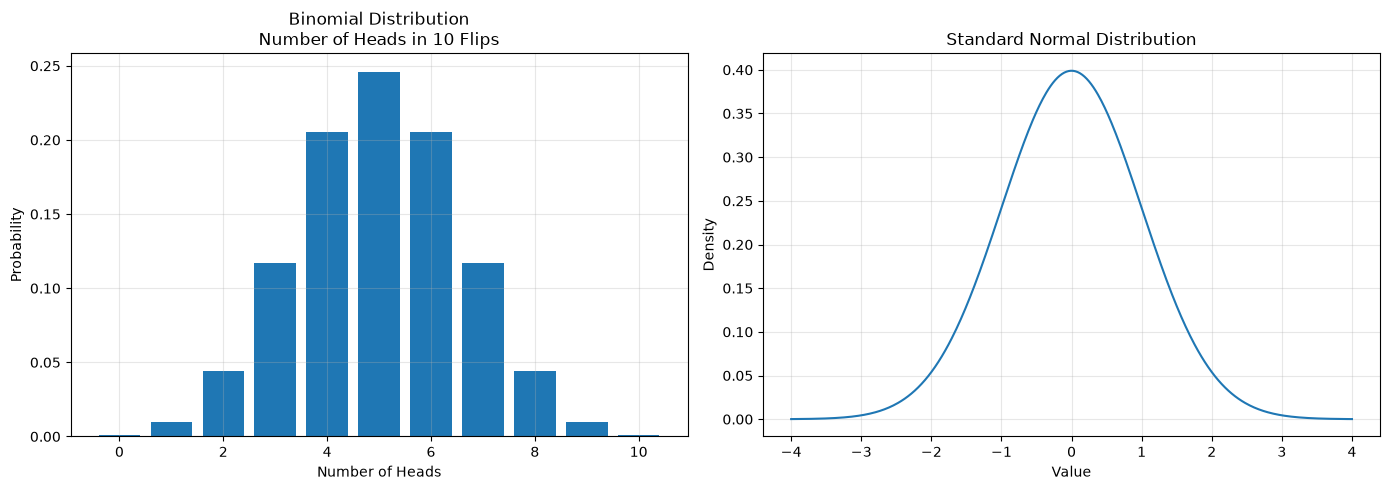


PART 5 — NORMAL DISTRIBUTION: WITHIN 1 STANDARD DEVIATION

P(-1 <= X <= 1) using normal CDF = 0.6826894921370859
Percentage = 68.26894921370858 %

--- Normal Distribution Simulation ---
Simulated P(within 1 standard deviation) = 0.682573
Theoretical probability = 0.6826894921370859
Simulated percentage = 68.2573 %

Simulation confirms approximately 68%? True

FINAL SUMMARY

Fair die E[X] = 3.5000
Fair die Var(X) = 2.9167
Fair die SD = 1.7078

Weighted die E[X] = 3.8571

Normal distribution probability within ±1 SD = 68.27%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# TASK 05 — Distributions, Expectation, and Variance
# ============================================================

# One reproducible random generator
rng = np.random.default_rng(0)


# ============================================================
# PART 1 — FAIR DIE
# ============================================================

# Possible values of a fair die
values = np.arange(1, 7)

# Every face has equal probability
probs = np.ones(6) / 6

print("=" * 65)
print("PART 1 — FAIR DIE")
print("=" * 65)

print("\nValues:", values)
print("Probabilities:", probs)


# ------------------------------------------------------------
# Expected Value
#
# E[X] = sum(x * P(X=x))
# ------------------------------------------------------------

E_X = np.sum(values * probs)

print("\nExpected Value E[X] =", E_X)


# ------------------------------------------------------------
# Variance
#
# Var(X) = E[X^2] - (E[X])^2
# ------------------------------------------------------------

E_X_squared = np.sum((values ** 2) * probs)

Var_X = E_X_squared - E_X ** 2

Std_X = np.sqrt(Var_X)

print("E[X^2] =", E_X_squared)
print("Variance Var(X) =", Var_X)
print("Standard Deviation =", Std_X)


# ------------------------------------------------------------
# Simulation of a fair die
# ------------------------------------------------------------

n = 100_000

fair_rolls = rng.integers(1, 7, size=n)

simulated_mean = np.mean(fair_rolls)
simulated_variance = np.var(fair_rolls)
simulated_std = np.std(fair_rolls)

print("\n--- Fair Die Simulation ---")

print("Number of rolls:", n)
print("Simulated mean =", simulated_mean)
print("Simulated variance =", simulated_variance)
print("Simulated standard deviation =", simulated_std)

print(
    "\nMean close to theoretical value?",
    np.isclose(simulated_mean, E_X, atol=0.01)
)

print(
    "Variance close to theoretical value?",
    np.isclose(simulated_variance, Var_X, atol=0.02)
)


# ============================================================
# PART 2 — WEIGHTED DIE
# ============================================================

print("\n" + "=" * 65)
print("PART 2 — WEIGHTED DIE")
print("=" * 65)

# A weighted die where 6 is twice as likely as every other face.
#
# Let the probability of each face 1-5 be p.
# Probability of 6 = 2p.
#
# Total probability:
#
# p + p + p + p + p + 2p = 1
#
# 7p = 1
# p = 1/7
#
# Therefore:
# Faces 1-5 = 1/7 each
# Face 6 = 2/7

weighted_probs = np.array([
    1/7,
    1/7,
    1/7,
    1/7,
    1/7,
    2/7
])

print("\nWeighted probabilities:")
for value, probability in zip(values, weighted_probs):
    print(f"{value}: {probability:.4f}")


# Check that probabilities add to 1
print("\nSum of probabilities =", weighted_probs.sum())


# ------------------------------------------------------------
# Expected value of weighted die
# ------------------------------------------------------------

weighted_E_X = np.sum(values * weighted_probs)

print("\nWeighted die E[X] =", weighted_E_X)


# ------------------------------------------------------------
# Simulate the weighted die
# ------------------------------------------------------------

weighted_rolls = rng.choice(
    values,
    size=n,
    p=weighted_probs
)

weighted_simulated_mean = np.mean(weighted_rolls)

print("\n--- Weighted Die Simulation ---")

print("Simulated weighted mean =", weighted_simulated_mean)

print(
    "Simulation close to theoretical value?",
    np.isclose(
        weighted_simulated_mean,
        weighted_E_X,
        atol=0.01
    )
)


# ------------------------------------------------------------
# Explain movement of expectation
# ------------------------------------------------------------

print(
    "\nWhy does expectation move up?",
    "Because the highest value, 6, now has more probability mass, "
    "so the weighted average shifts toward 6."
)


# ============================================================
# PART 3 — BINOMIAL DISTRIBUTION
# ============================================================

print("\n" + "=" * 65)
print("PART 3 — BINOMIAL DISTRIBUTION")
print("=" * 65)

# Number of heads in 10 fair coin flips
n_flips = 10
p_heads = 0.5

x_binom = np.arange(0, n_flips + 1)

# scipy.stats.binom.pmf gives P(X = x)
binom_probs = stats.binom.pmf(
    x_binom,
    n_flips,
    p_heads
)

print("\nNumber of flips:", n_flips)
print("Probability of heads:", p_heads)

print("\nBinomial probabilities:")
for x, probability in zip(x_binom, binom_probs):
    print(f"Heads = {x}: P(X={x}) = {probability:.4f}")


# ============================================================
# PART 4 — NORMAL DISTRIBUTION
# ============================================================

print("\n" + "=" * 65)
print("PART 4 — NORMAL DISTRIBUTION")
print("=" * 65)

mu = 0
sigma = 1

x_normal = np.linspace(
    mu - 4 * sigma,
    mu + 4 * sigma,
    500
)

normal_pdf = stats.norm.pdf(
    x_normal,
    loc=mu,
    scale=sigma
)


# ------------------------------------------------------------
# Plot both distributions side by side
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binomial distribution
axes[0].bar(
    x_binom,
    binom_probs
)

axes[0].set_title(
    "Binomial Distribution\nNumber of Heads in 10 Flips"
)

axes[0].set_xlabel("Number of Heads")
axes[0].set_ylabel("Probability")
axes[0].grid(alpha=0.3)


# Normal distribution
axes[1].plot(
    x_normal,
    normal_pdf
)

axes[1].set_title(
    "Standard Normal Distribution"
)

axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# PART 5 — WITHIN ONE STANDARD DEVIATION
# ============================================================

print("\n" + "=" * 65)
print("PART 5 — NORMAL DISTRIBUTION: WITHIN 1 STANDARD DEVIATION")
print("=" * 65)

# For a standard normal:
#
# Mean = 0
# Standard deviation = 1
#
# Within one standard deviation means:
#
# -1 <= X <= 1

P_within_1_sd = (
    stats.norm.cdf(1)
    - stats.norm.cdf(-1)
)

print(
    "\nP(-1 <= X <= 1) using normal CDF =",
    P_within_1_sd
)

print(
    "Percentage =",
    P_within_1_sd * 100,
    "%"
)


# ------------------------------------------------------------
# Monte Carlo simulation for the 68% rule
# ------------------------------------------------------------

normal_samples = rng.normal(
    loc=mu,
    scale=sigma,
    size=1_000_000
)

within_1_sd = (
    (normal_samples >= mu - sigma)
    &
    (normal_samples <= mu + sigma)
)

P_within_1_sd_simulated = within_1_sd.mean()

print("\n--- Normal Distribution Simulation ---")

print(
    "Simulated P(within 1 standard deviation) =",
    P_within_1_sd_simulated
)

print(
    "Theoretical probability =",
    P_within_1_sd
)

print(
    "Simulated percentage =",
    P_within_1_sd_simulated * 100,
    "%"
)

print(
    "\nSimulation confirms approximately 68%?",
    np.isclose(
        P_within_1_sd_simulated,
        P_within_1_sd,
        atol=0.005
    )
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

print(f"\nFair die E[X] = {E_X:.4f}")
print(f"Fair die Var(X) = {Var_X:.4f}")
print(f"Fair die SD = {Std_X:.4f}")

print(f"\nWeighted die E[X] = {weighted_E_X:.4f}")

print(
    f"\nNormal distribution probability within ±1 SD "
    f"= {P_within_1_sd * 100:.2f}%"
)